## MedDec Decision Extraction | Training Notebook for Colab

**Goal**: Fine-tune ELECTRA on the MedDec MIMIC-III dataset to detect and classify medical decision spans.

**Pre-requisites:**
- Upload data to Google Drive (`02 Data/meddec-mimic-iii/`)
- Upload or pull code repository to Google Drive

---

## Step 1a. Setup

In [1]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [2]:
# Install required packages
!pip install -q transformers mlflow tqdm #transformers==4.39.3

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.4/49.4 kB 651.1 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 36.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 103.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 70.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.3/86.3 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 50.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [3]:
import shutil, sys
from pathlib import Path

# Paths (EDIT IF NEEDED!!)
DRIVE_CODE_DIR = Path("/content/drive/MyDrive/AI4H-project-rework/04 Code/04 Code/med-decision-extraction")
DRIVE_DATA_DIR = Path("/content/drive/MyDrive/AI4H-project-rework/02 Data")

# Copy .py files to fast local storage (/content)
LOCAL_CODE = Path("/content/meddec")
if LOCAL_CODE.exists():
    shutil.rmtree(LOCAL_CODE)
shutil.copytree(DRIVE_CODE_DIR, LOCAL_CODE)
sys.path.insert(0, str(LOCAL_CODE))

# Verify paths and files
print("Code at :", LOCAL_CODE)
print("Data at :", DRIVE_DATA_DIR)
print("Files   :", [f.name for f in LOCAL_CODE.glob("*.py")])

Code at : /content/meddec
Data at : /content/drive/MyDrive/AI4H-project-rework/02 Data
Files   : ['model.py', 'train.py', 'preprocess_phenos.py', 'build_splits.py', 'evaluate.py', 'dataset.py', 'build_stats.py', 'extract_texts.py']


## Step 1b. Verify setup

In [4]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [5]:
MEDDEC_DIR = DRIVE_DATA_DIR / "meddec-mimic-iii"
SPLITS_DIR = MEDDEC_DIR / "splits"

checks = {
    "meddec-mimic-iii/data/"    : (MEDDEC_DIR / "data").exists(),
    "meddec-mimic-iii/raw_text/": (MEDDEC_DIR / "raw_text").exists(),
    "splits/train.txt"          : (SPLITS_DIR / "train.txt").exists(),
    "splits/val.txt"            : (SPLITS_DIR / "val.txt").exists(),
    "splits/test.txt"           : (SPLITS_DIR / "test.txt").exists(),
}

all_ok = True
for name, ok in checks.items():
    status = "OK" if ok else "MISSING"
    print(f"  [{status:7s}] {name}")
    if not ok:
        all_ok = False

if not all_ok:
    raise RuntimeError("Some required paths are missing. Run data prep phase before training.")

n_json = len(list((MEDDEC_DIR / "data").glob("*.json")))
n_txt  = len(list((MEDDEC_DIR / "raw_text").glob("*.txt")))
print(f"\nJSON annotations : {n_json}")
print(f"Raw text files   : {n_txt}")

  [OK     ] meddec-mimic-iii/data/
  [OK     ] meddec-mimic-iii/raw_text/
  [OK     ] splits/train.txt
  [OK     ] splits/val.txt
  [OK     ] splits/test.txt

JSON annotations : 403
Raw text files   : 403


## Step 1c. Setup MLflow

Points MLflow at a Google Drive folder `mlruns/` so that experiment runs survive Colab resets. Check later section for plots etc.

In [7]:
%env MLFLOW_ALLOW_FILE_STORE=true

env: MLFLOW_ALLOW_FILE_STORE=true


In [8]:
import mlflow

MLFLOW_DIR = DRIVE_DATA_DIR / "mlruns"      # persisted to Drive
MLFLOW_DIR.mkdir(parents=True, exist_ok=True)
mlflow.set_tracking_uri(f"file://{MLFLOW_DIR}")

print("MLflow tracking URI:", mlflow.get_tracking_uri())
print("Existing experiments:", [e.name for e in mlflow.search_experiments()])

MLflow tracking URI: file:///content/drive/MyDrive/AI4H-project-rework/02 Data/mlruns
Existing experiments: []


## Step 2. Training

Checkpoints are saved to `/content/checkpoints/` (fast SSD).  

***Note!!*** Copy `best_model.pt` back to Drive after training (tbd) OR download the .pt file

In [9]:
from train import train

OUTPUT_DIR = Path("/content/checkpoints")

model = train(
    meddec_dir   = MEDDEC_DIR,
    splits_dir   = SPLITS_DIR,
    output_dir   = OUTPUT_DIR,
    model_name   = "google/electra-base-discriminator",
    num_epochs   = 5,
    batch_size   = 4,
    lr           = 4e-5,
    grad_accum   = 2,
    warmup_ratio = 0.1,
    max_len      = 512,
    experiment   = "meddec-electra",
)

Device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

...

Epoch  3 | train_loss=0.9162 | val_loss=0.8320 | val_token_acc=0.722
  → Checkpoint saved: /content/checkpoints/best_model.pt


Epoch 4/5: 100%|██████████| 81/81 [00:31<00:00,  2.61it/s, loss=0.9058]


Epoch  4 | train_loss=0.8016 | val_loss=0.7360 | val_token_acc=0.757
  → Checkpoint saved: /content/checkpoints/best_model.pt


Epoch 5/5: 100%|██████████| 81/81 [00:31<00:00,  2.60it/s, loss=0.2710]


Epoch  5 | train_loss=0.7358 | val_loss=0.7202 | val_token_acc=0.757
  → Checkpoint saved: /content/checkpoints/best_model.pt
Training complete.


## Step 2b. Training results

`mlflow.search_runs()` returns a DataFrame — one row per run, one column per logged metric/param.  
We then pull per-epoch values via `MlflowClient.get_metric_history()` to draw loss curves.

In [10]:
import mlflow
import pandas as pd

runs = mlflow.search_runs(experiment_names=["meddec-electra"], order_by=["start_time DESC"],)

# Pretty-print the most recent run's hyperparams + final metrics
latest   = runs.iloc[0]
run_id   = latest["run_id"]

params  = {k.replace("params.", ""): v for k, v in latest.items() if k.startswith("params.") and pd.notna(v)}
metrics = {k.replace("metrics.", ""): round(float(v), 4) for k, v in latest.items() if k.startswith("metrics.") and pd.notna(v)}

print("=== Latest Run ===")
print(f"Run ID: {run_id}")
print(f"Status: {latest['status']}")
print()
print("Hyperparameters:")
for k, v in params.items():
    print(f"  {k:20s} = {v}")
print()
print("Final metrics:")
for k, v in metrics.items():
    print(f"  {k:25s} = {v}")

=== Latest Run ===
Run ID: 70e2931a104c4e9c92a01359fd029c1d
Status: FINISHED

Hyperparameters:
  grad_accum           = 2
  total_steps          = 200
  num_epochs           = 5
  lr                   = 4e-05
  val_samples          = 38
  model_name           = google/electra-base-discriminator
  train_samples        = 324
  warmup_ratio         = 0.1
  batch_size           = 4
  max_len              = 512

Final metrics:
  val_loss                  = 0.7202
  epoch_train_loss          = 0.7358
  val_token_acc             = 0.7575
  train_loss                = 0.7416
  best_val_loss             = 0.7202


In [11]:
import matplotlib.pyplot as plt

client = mlflow.tracking.MlflowClient()

def get_history(metric_name):
    """Return list of (step, value) for a metric in the latest run."""
    return [(m.step, m.value) for m in client.get_metric_history(run_id, metric_name)]

train_loss_hist = get_history("epoch_train_loss")
val_loss_hist   = get_history("val_loss")
val_acc_hist    = get_history("val_token_acc")

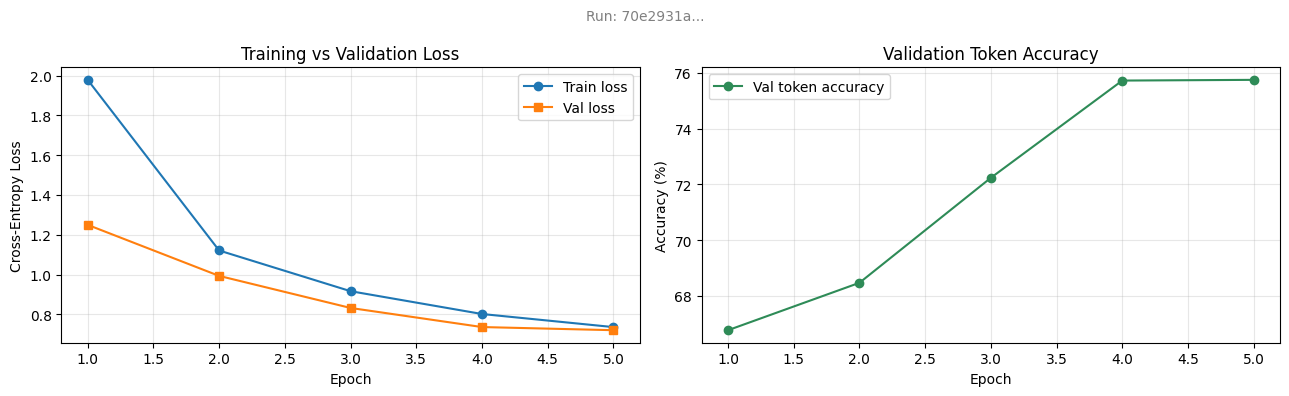

Val loss decreased across training. Model converged normally.


In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# Loss plot
if train_loss_hist:
    epochs, vals = zip(*train_loss_hist)
    ax1.plot(epochs, vals, label="Train loss", marker="o")
if val_loss_hist:
    epochs, vals = zip(*val_loss_hist)
    ax1.plot(epochs, vals, label="Val loss", marker="s")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Cross-Entropy Loss")
ax1.set_title("Training vs Validation Loss")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Token accuracy plot
if val_acc_hist:
    epochs, vals = zip(*val_acc_hist)
    ax2.plot(epochs, [v * 100 for v in vals], label="Val token accuracy", marker="o", color="seagreen")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy (%)")
ax2.set_title("Validation Token Accuracy")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle(f"Run: {run_id[:8]}...", fontsize=10, color="grey")
plt.tight_layout()
plt.show()

# Warn if model may not have converged
if val_loss_hist and val_loss_hist[-1][1] >= val_loss_hist[0][1]:
    print("WARNING: val loss did not decrease — model may not have converged. Try more epochs.")
else:
    print("Val loss decreased across training. Model converged normally.")

## Step 2c. Save checkpoint to Drive

During the training run, checkpoints were saved to `/content/checkpoints/` (fast local SSD). Now we save them to the working Colab directory.

***IMPORTANT:*** Remember to download and save the .pt files!

In [13]:
import shutil

DRIVE_CKPT_DIR = DRIVE_DATA_DIR / "checkpoints"
DRIVE_CKPT_DIR.mkdir(parents=True, exist_ok=True)

for fname in ["best_model.pt", "last_model.pt"]:
    src = OUTPUT_DIR / fname
    dst = DRIVE_CKPT_DIR / fname
    if src.exists():
        shutil.copy(src, dst)
        size_mb = src.stat().st_size / 1e6
        print(f"Saved {fname} ({size_mb:.0f} MB) → {dst}")
    else:
        print(f"WARNING: {fname} not found in {OUTPUT_DIR}")

Saved best_model.pt (436 MB) → /content/drive/MyDrive/AI4H-project-rework/02 Data/checkpoints/best_model.pt
Saved last_model.pt (436 MB) → /content/drive/MyDrive/AI4H-project-rework/02 Data/checkpoints/last_model.pt


## Step 2d. Sanity check: Load checkpoint, produce output

Print token-level predictions for the first 20 tokens of the first validation note.

In [14]:
import torch
from model import MedDecModel
from dataset import load_electra_tokenizer, make_dataloader, NUM_LABELS

device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer = load_electra_tokenizer()

In [15]:
# Load the best checkpoint (saved in current Colab session local storage!!!)
model_ckpt = MedDecModel(num_labels=NUM_LABELS).to(device)
model_ckpt.load_state_dict(torch.load(OUTPUT_DIR / "best_model.pt", map_location=device))
model_ckpt.eval()
print("Checkpoint loaded.")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] ElectraModel LOAD REPORT from: google/electra-base-discriminator
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
discriminator_predictions.dense.bias              | UNEXPECTED |  | 
discriminator_predictions.dense.weight            | UNEXPECTED |  | 
electra.embeddings_project.bias                   | UNEXPECTED |  | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED |  | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED |  | 
electra.embeddings_project.weight                 | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Checkpoint loaded.


In [16]:

# Run one batch from the validation set
val_loader = make_dataloader(SPLITS_DIR / "val.txt", MEDDEC_DIR, tokenizer, train=False, batch_size=1, max_len=512,)
batch  = next(iter(val_loader))
ids    = batch["input_ids"][:, :512].to(device)
mask   = batch["attention_mask"][:, :512].to(device)
labels = batch["labels"][:, :512]

with torch.no_grad():
    logits = model_ckpt(ids, mask)

preds  = logits.argmax(-1)[0].cpu().tolist()
gold   = labels[0].tolist()

print(f"Input  : {ids.shape}")
print(f"Logits : {logits.shape}   (batch=1, seq_len, 19 label classes)")
print()

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (1176 > 512). Running this sequence through the model will result in indexing errors


Input  : torch.Size([1, 512])
Logits : torch.Size([1, 512, 19])   (batch=1, seq_len, 19 label classes)



In [19]:
# Decode first 20 tokens with predicted + gold labels
LABEL_NAMES = (
    {i * 2:     f"B-Cat{i+1}" for i in range(9)}
    | {i * 2 + 1: f"I-Cat{i+1}" for i in range(9)}
    | {18: "O", -100: "PAD"}
)

print(f"{'Tok':>4}  {'Token':20s}  {'Gold':12s}  {'Pred':12s}")
print("-" * 55)
for idx in range(min(20, ids.shape[1])):
    tok_str   = tokenizer.decode([ids[0, idx].item()])
    gold_str  = LABEL_NAMES.get(gold[idx],  str(gold[idx]))
    pred_str  = LABEL_NAMES.get(preds[idx], str(preds[idx]))
    match     = "" if gold[idx] == -100 else ("✓" if gold[idx] == preds[idx] else "✗")
    print(f"{idx:>4}  {tok_str:20s}  {gold_str:12s}  {pred_str:12s}  {match}")

 Tok  Token                 Gold          Pred        
-------------------------------------------------------
   0  [CLS]                 PAD           O             
   1  admission             O             O             ✓
   2  date                  O             O             ✓
   3  :                     O             O             ✓
   4  [                     O             O             ✓
   5  *                     O             O             ✓
   6  *                     O             O             ✓
   7  213                   O             O             ✓
   8  ##8                   O             O             ✓
   9  -                     O             O             ✓
  10  3                     O             O             ✓
  11  -                     O             O             ✓
  12  20                    O             O             ✓
  13  *                     O             O             ✓
  14  *                     O             O             ✓
  15  ]             

---

## Next Steps

Training is complete. The token-level accuracy above is a **proxy metric** — it counts every O token as a correct prediction, which inflates the number.  

The real evaluation metric is **span-level F1**: a prediction is a true positive only if the exact (sample, category, start_token, end_token) tuple matches a gold annotation.

That is implemented in **Phase 2.4 — `evaluate.py`**:
- BIO decoding: scan predictions for `B-n` → `I-n` → `I-n` ... chains → extract (start, end, category) spans
- Compare predicted spans to gold spans
- Report precision, recall, F1 per category + macro F1

**Target**: span F1 ≈ 0.3–0.5 on this dataset size (full dataset + full training → 0.782 per Elgaar et al., 2024)


## Step 3. Evaluation

Metric: Span-level F1, a prediction is a true positive only if the exact `(category, start_token, end_token)` matches a gold annotation.

In [7]:
# (Optional) If starting from a new Colab session, run 1a + 1b first, and then this
import torch
from pathlib import Path
from model import MedDecModel
from dataset import load_electra_tokenizer, NUM_LABELS


device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer = load_electra_tokenizer()

# EDIT: configure the checkpoint path
#CHECKPOINT_PATH = Path("/content/best_model.pt") #Path("/content/checkpoints/best_model.pt")
CHECKPOINT_PATH = DRIVE_DATA_DIR / "checkpoints" / "best_model.pt" # loading from the drive

model_eval = MedDecModel(num_labels=NUM_LABELS).to(device)
state_dict = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=True)
model_eval.load_state_dict(state_dict)
model_eval.eval()

print(f"Checkpoint : {CHECKPOINT_PATH}")
print(f"Device     : {device}")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] ElectraModel LOAD REPORT from: google/electra-base-discriminator
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
discriminator_predictions.dense_prediction.bias   | UNEXPECTED |  | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED |  | 
discriminator_predictions.dense.weight            | UNEXPECTED |  | 
discriminator_predictions.dense.bias              | UNEXPECTED |  | 
electra.embeddings_project.weight                 | UNEXPECTED |  | 
electra.embeddings_project.bias                   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Checkpoint : /content/drive/MyDrive/AI4H-project-rework/02 Data/checkpoints/best_model.pt
Device     : cpu


In [8]:
from evaluate import evaluate, print_results
from dataset import MedDecDataset

# Load test dataset
test_dataset = MedDecDataset(SPLITS_DIR / "test.txt", MEDDEC_DIR, tokenizer,train=False,)
print(f"Test set: {len(test_dataset)} notes\n")

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (2326 > 512). Running this sequence through the model will result in indexing errors


Test set: 41 notes



In [9]:
results = evaluate(model_eval, test_dataset, device)
print_results(results, split_name="test")


  Span-level F1 — TEST SET
  Gold spans :  5228
  Pred spans :  5725
  TP=738  FP=4987  FN=4490
  Precision  : 0.1289
  Recall     : 0.1412
  F1         : 0.1348  ← main metric

  Cat  Name                           F1       P       R   Gold   Pred
  ------------------------------------------------------------
    1  Contact-related             0.065   0.052   0.089    270    463
    2  Gathering information       0.000   0.000   0.000     33      0
    3  Defining problem            0.133   0.136   0.130   2100   1995
    4  Treatment goal              0.000   0.000   0.000     12      0
    5  Drug                        0.243   0.239   0.247   1314   1355
    6  Therapeutic procedure       0.117   0.103   0.135    519    681
    7  Evaluating test result      0.049   0.044   0.055    748    937
    8  Deferment                   0.000   0.000   0.000      8      0
    9  Advice and precaution       0.027   0.024   0.031    224    294

